In [18]:
import plotly.express as px
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [19]:
colors = px.colors.qualitative.Dark24

# ensure same colors for regular and no_s1 lines
color_map = {
    "Own USD Weights": colors[0],
    "Own USD Weights, no S1": colors[0],
    "Russian USD Weights": colors[6],
    "Russian USD Weights, no S1": colors[6],
    "Finnish USD Weights": colors[2],
    "Finnish USD Weights, no S1": colors[2],
    "euclidean": colors[3],
    "euclidean, no S1": colors[3],
    "norm_l1": colors[4],
    "norm_l1, no S1": colors[4],
}

# add data to lineplot
def add_lineplot(ax, result_path: str, models: list[str], legend: bool):
    df_result = pd.read_csv(result_path, sep="\t", dtype={"result_name": str, "precision": float, "recall": float, "t1_original": float, "t3_original": float})

    for model in models:
        per_model_rows = df_result[df_result["result_name"] == model]
        model_name = per_model_rows["result_name"].iloc[0]
        model_color = color_map[model_name]
        label = None
        if legend:
            label = model_name
        linestyle = '-'
        if "no S1" in model_name:
            label=None
            linestyle = "--"
        sns.lineplot(data=per_model_rows, x="valid_p_count", y="Precision", ax=ax, color=model_color, label=label,
                     linestyle=linestyle, marker=None, legend=False)
        ax.set_xlabel("")
        ax.set_ylabel("")


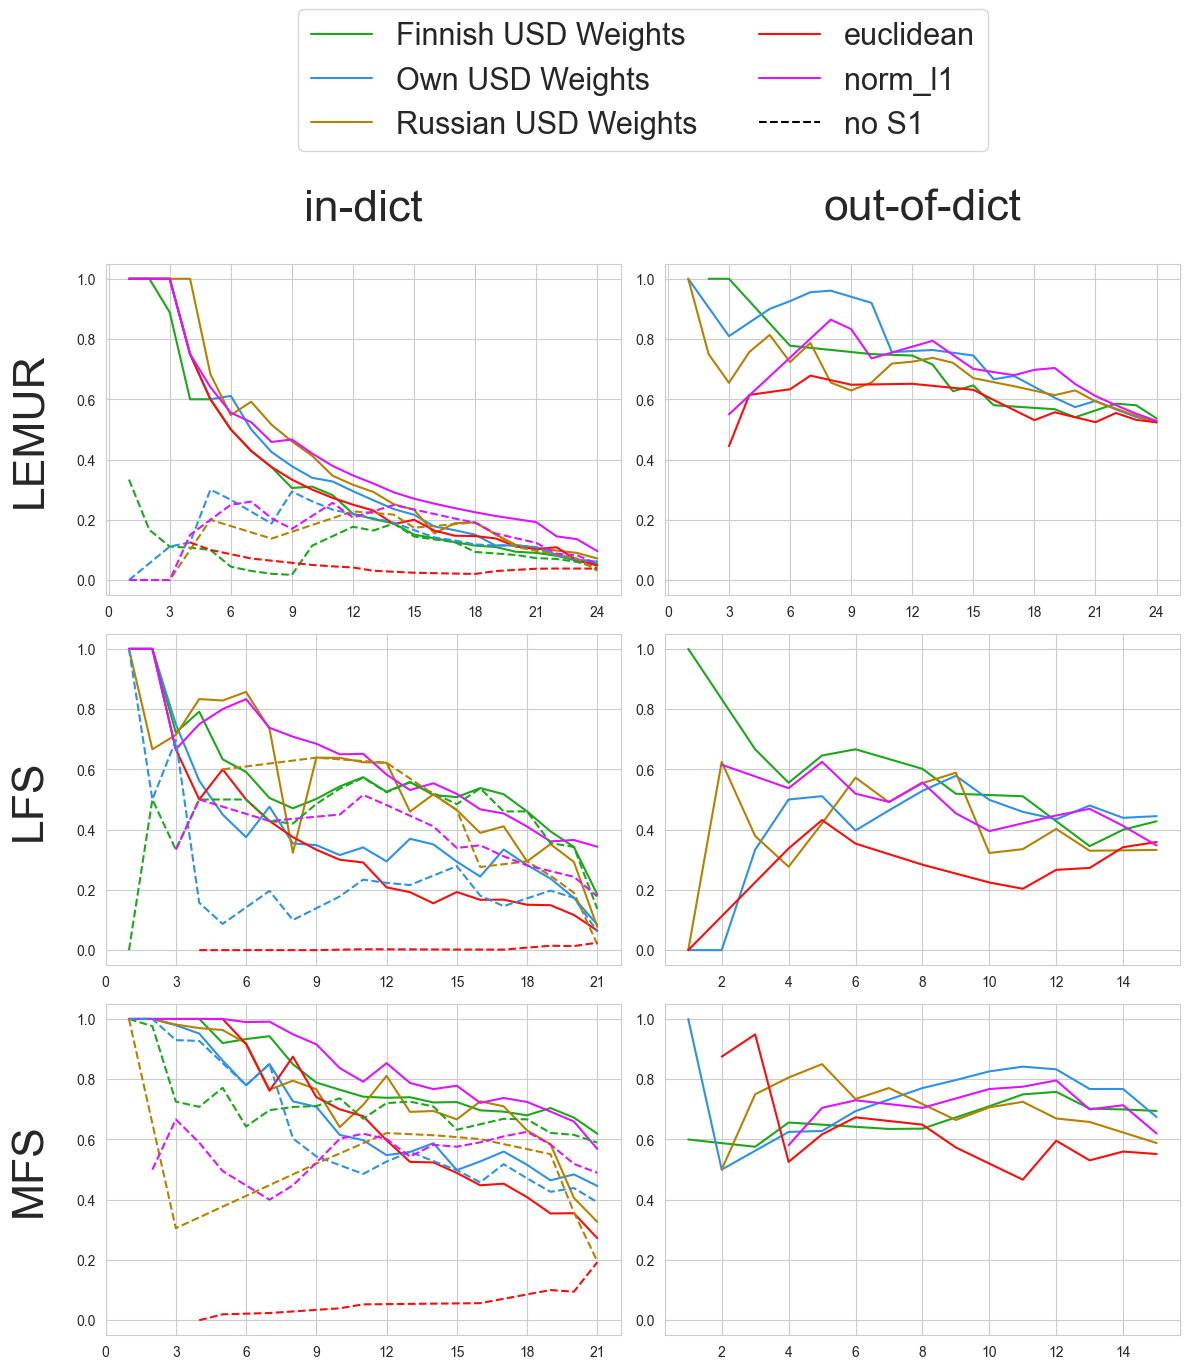

In [20]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


sns.set_style("whitegrid")

# result data to plot
results = [
    "in_dict.tsv",
    "out_of_dict.tsv",
    "LFS_in_dict.tsv",
    "LFS_out_of_dict.tsv",
    "MFS_in_dict.tsv",
    "MFS_out_of_dict.tsv"
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False, sharey=False)
axes_flat = axes.ravel()

show_legend = False
for num, (axis, result) in enumerate(zip(axes_flat, results)):
    if num == 0:
        show_legend = True
    models = pd.read_csv(result, sep="\t", dtype=str)["result_name"].unique()
    add_lineplot(axis, result, models, show_legend)
    show_legend = False

    axis.set_ylim(-0.05, 1.05)

# set column labels
column_labels = ["in-dict", "out-of-dict"]
for j, col_label in enumerate(column_labels):
    axes[0, j].annotate(
        col_label,
        xy=(0.5, 1),
        xytext=(0, 25),
        xycoords='axes fraction',
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=32
    )

# set row labels
row_labels = ["LEMUR", "LFS", "MFS"]
for i, row_label in enumerate(row_labels):
    axes[i, 0].annotate(
        row_label,
        xy=(0, 0.5),
        xytext=(-40, 0),
        xycoords='axes fraction',
        textcoords='offset points',
        ha='right',
        va='center',
        fontsize=32,
        rotation=90
    )

# setup legend
handles, labels = axes_flat[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
custom_line = Line2D([0], [0], color="black", linestyle="--")
unique["no S1"] = custom_line
fig.legend(
    unique.values(),
    unique.keys(),
    loc='upper center',
    bbox_to_anchor=(0.54, 1.15),
    ncol=len(models),
    frameon=True,
    fontsize=22,
    ncols=2
)

for ax in axes_flat:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))


plt.tight_layout()
plt.show()
fig.savefig("lineplots.png", dpi=400, bbox_inches='tight')